# Preliminary Analysis on Base Questions

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.width', 1000)

## Cleaning datasets

We used the MBTA bus ridership dataset, 'MBTA_Bus_Ridership_Fall_2019.csv' and 'MBTA_Bus_Ridership_Fall_2022.csv'.

This code will transform the ridership data by multiplying the average "alightings/boarding" with "sample_size" and return total "alightings/boarding". 

In [5]:
def clean_data(filename):
    
    # Loads file
    file = pd.read_csv(filename, low_memory=False)

    # Calculates total boarding and alightings for each stop
    file['total_boardings'] = file['boardings'] * file['sample_size']
    file['total_alightings'] = file['alightings'] * file['sample_size']

    return file.drop(['boardings', 'alightings', 'sample_size'], axis=1)

## Question 1

In [25]:
def ridership(filename):
    # This function will calculuate ridership per busline based on file

    # Loads file
    file = clean_data(filename)

    # Calculates total ridership of bus routes
    ridership = file['total_boardings'].sum()
    # Calculates boardings and alightings by bus routes
    ridership_by_stop = file.groupby('route_id')[['total_boardings', 'total_alightings']].sum()
    # Calculates the differences of ridership per bus routes
    ridership_by_stop["difference"] = ridership_by_stop['total_boardings'] - ridership_by_stop['total_alightings']
    
    # Create a copy of the original dataframe with the specific columns
    copy_df = file[['route_id', 'trip_start_time', 'stop_name', 'total_boardings', 'total_alightings']].copy()
    # Gets the index of the peak boarding and alightings using 'idxmax()'
    peak_ridership_idx = copy_df.groupby('route_id')[['total_boardings', 'total_alightings']].idxmax()
    # Use the index from 'peak_ridership_idx' to get the rows with peak ridership
    # Extract the rows corresponding to peak boardings
    peak_boardings = copy_df.loc[peak_ridership_idx['total_boardings'], ['route_id', 'trip_start_time', 'stop_name', 'total_boardings']]
    # Extract the rows corresponding to peak alightings
    peak_alightings = copy_df.loc[peak_ridership_idx['total_alightings'], ['route_id', 'trip_start_time', 'stop_name', 'total_alightings']]
    
    # Plot total boarding and alightings by bus routes
    plt.figure(figsize=(14, 6)) # Extends figure size
    plt.scatter(ridership_by_stop.index.astype(str), (ridership_by_stop['total_boardings'] / 10000), color = 'blue', s = 10, alpha = 0.75, label='Boardings') # Assigns scatterplot of bus route vs boarding as "blue"
    plt.scatter(ridership_by_stop.index.astype(str), (ridership_by_stop['total_alightings'] / 10000), color = 'red', s = 10, alpha = 0.5, label='Alightings') # Assigns scatterplot of bus route vs alightings as "red"
    plt.title("Ridership by Bus Route")
    plt.xlabel("Bus Routes")
    plt.ylabel("Boarding and Alightings (in 10,000s)")
    plt.xticks(rotation=270, fontsize=6)
    plt.tight_layout()
    plt.legend()
    plt.grid(True)
    plt.show()
   


    # Plot the difference between peak boarding and peak alightings.
    plt.figure(figsize=(14, 6)) # Extends figure size
    plt.scatter(ridership_by_stop.index.astype(str), ridership_by_stop['difference'] /1000, s = 10) # Plots scatterplot bus route vs difference between boarding and alightings
    plt.title("Difference of Ridership by Bus Route")
    plt.xlabel("Bus Routes")
    plt.ylabel("Difference between Boarding and Alightings (in 1,000s)")
    plt.xticks(rotation=270, fontsize=6)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    print(f"Total ridership is {ridership}. \n")
    # Returns dataframe of ridership, peak boarding times, and peak alightings per bus route.
    print(f"This table shows the ridership by bus routes.  \n \n {ridership_by_stop} \n")
    print(f"This table shows the peak boarding times per bus route. \n \n {peak_boardings} \n")
    print(f"This table shows the peak alightings times per bus route. \n \n {peak_alightings}")

#### Ridership Information for 2019

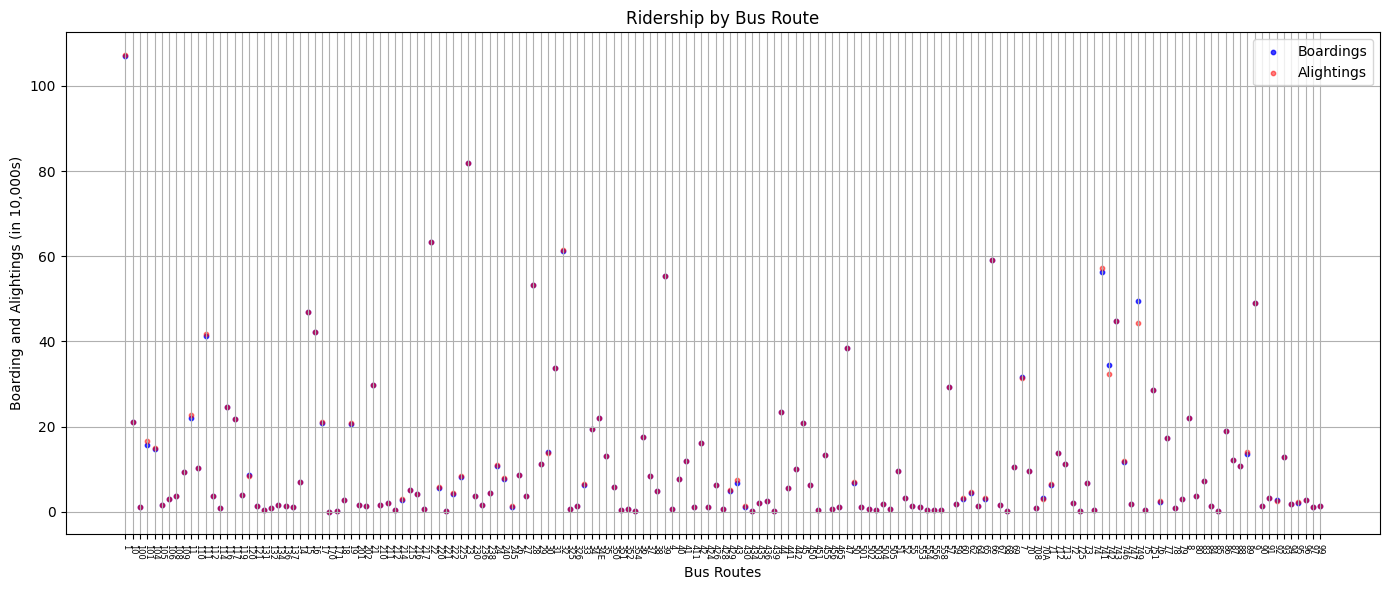

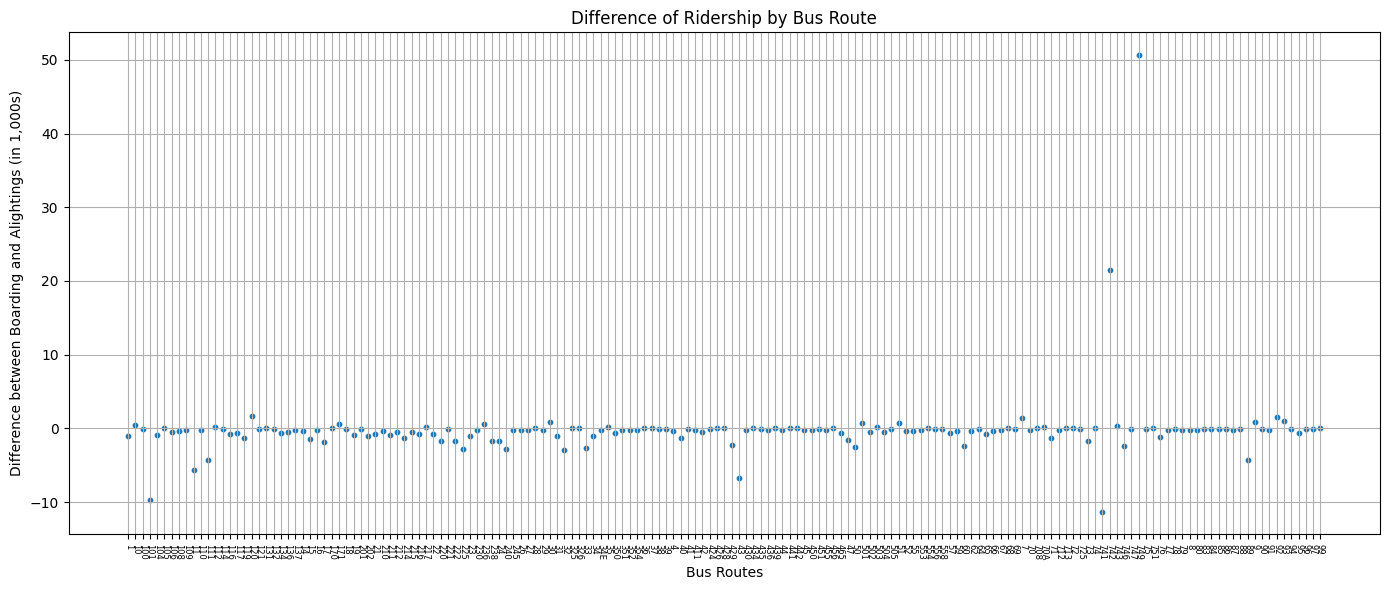

Total ridership is 18764633.699969. 

This table shows the ridership by bus routes.  
 
           total_boardings  total_alightings  difference
route_id                                               
1               1070984.6         1071975.8      -991.2
10               210140.8          209644.5       496.3
100               11920.0           12015.6       -95.6
101              156308.9          166011.5     -9702.6
104              148331.6          149217.3      -885.7
...                   ...               ...         ...
94                18115.9           18145.6       -29.7
95                21452.3           22114.9      -662.6
96                27485.5           27529.4       -43.9
97                10136.0           10178.7       -42.7
99                12610.9           12587.3        23.6

[165 rows x 3 columns] 

This table shows the peak boarding times per bus route. 
 
        route_id trip_start_time                    stop_name  total_boardings
1417          1    

In [31]:
ridership('MBTA_Bus_Ridership_Fall_2019.csv')

#### Ridership Information for 2022

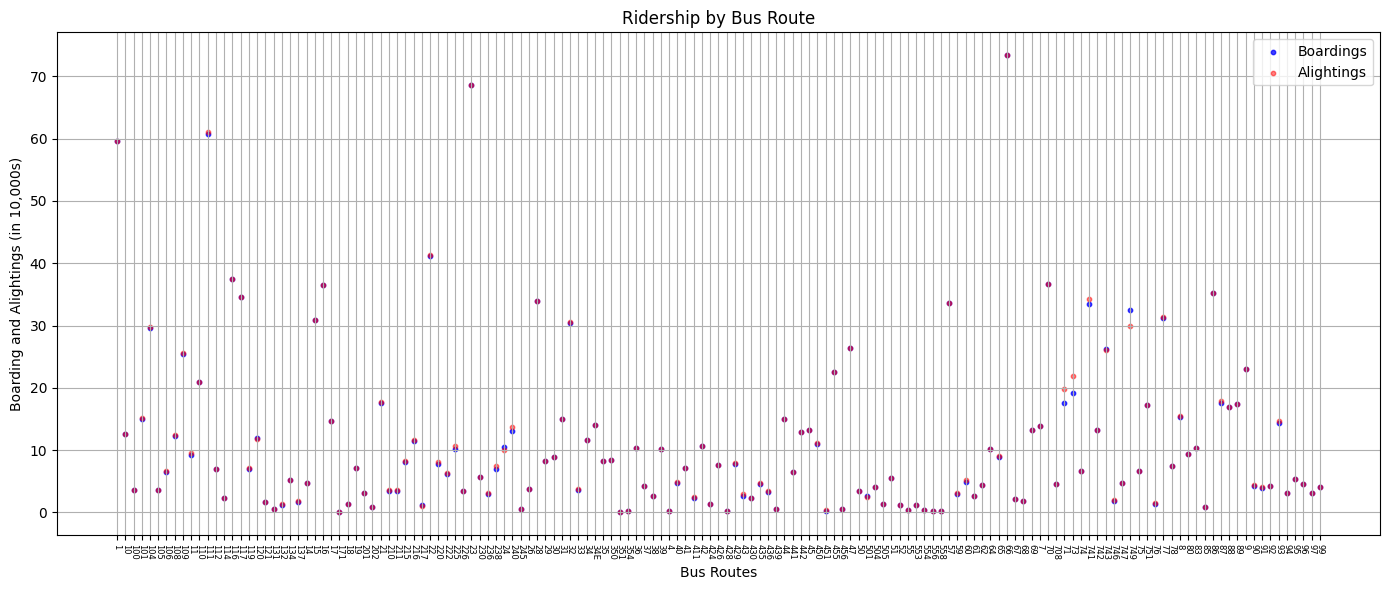

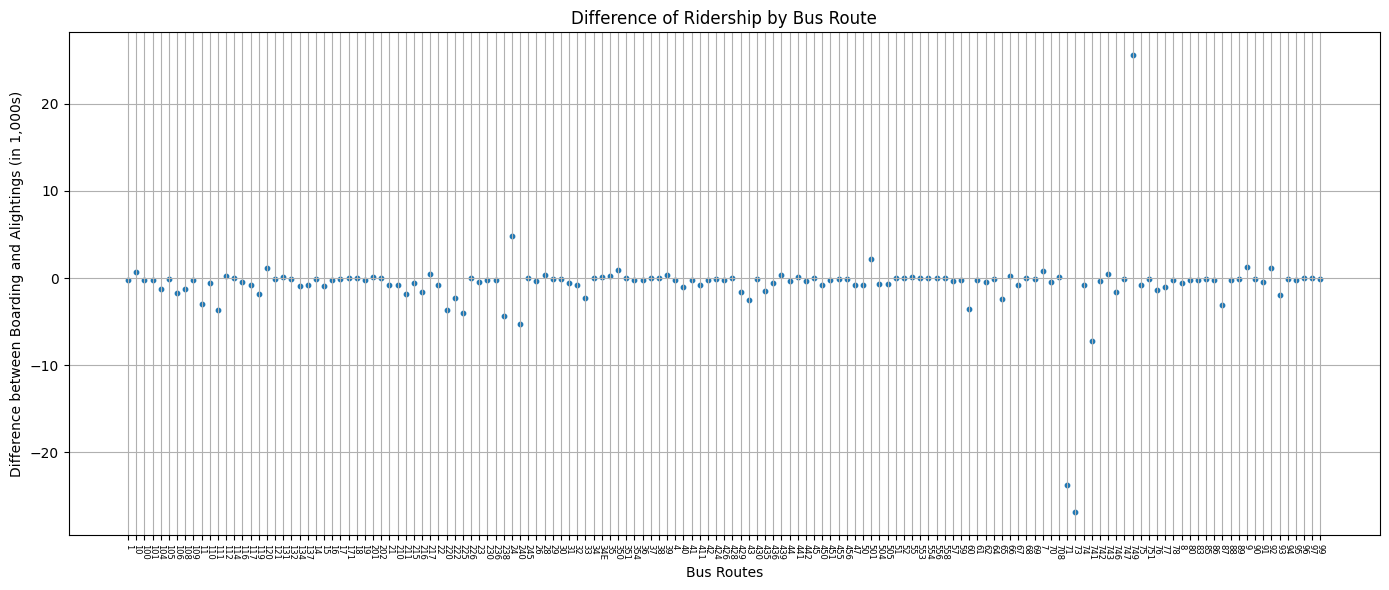

Total ridership is 16763366.7. 

This table shows the ridership by bus routes.  
 
           total_boardings  total_alightings  difference
route_id                                               
1                595944.2          596192.5      -248.3
10               126724.7          126064.2       660.5
100               36417.1           36643.9      -226.8
101              150782.0          151046.8      -264.8
104              296804.2          298002.0     -1197.8
...                   ...               ...         ...
94                30530.2           30667.7      -137.5
95                53999.6           54253.3      -253.7
96                45616.1           45619.1        -3.0
97                31631.4           31571.4        60.0
99                40613.1           40772.3      -159.2

[147 rows x 3 columns] 

This table shows the peak boarding times per bus route. 
 
        route_id trip_start_time                    stop_name  total_boardings
540           1        0

In [27]:
ridership('MBTA_Bus_Ridership_Fall_2022.csv')